# Métodos de *machine learning* para atribución de autoría

En este notebook se presentan algunos métodos de *machine learning* para atribución de autoría. En concreto, se van a realizar tres experimetos usando diferentes conjuntos de características y diferentes algoritmos de clasificación.

En cuanto a los conjuntos de características, se van a usar:

* Solo características estilométricas.
* Solo las palabras funcionales más frecuentes en el texto.
* Una combinación de ambas.

En cuanto a los algoritmos de clasificación, se van a usar:

* Regresión logística
* Linear SVC
* SVC con kernel RBF
* Random Forest
* KNN
* Naive Bayes

El objetivo de este notebook es comparar el rendimiento de estos métodos en la tarea de atribución de autoría y analizar cuáles son las características más relevantes a la hora de identificar al autor de un texto.

In [1]:
from pathlib import Path
from tqdm.auto import tqdm
from joblib import dump

import json
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from whodunit_stylometry.constants import STOPWORDS

from whodunit_stylometry.utils.nlp_utils import build_mfw_features, transform_with_mfw
from whodunit_stylometry.utils.stats_utils import drop_highly_correlated_features
from whodunit_stylometry.utils.plot_utils import plot_confussion_matrix
from whodunit_stylometry.utils.train_utils import run_experiment

## Configuración

In [2]:
SEED = 42
TOP_N_MFW = 50
KEEP_CORRELATED_FEATURES = False
CORRELATION_THRESHOLD = 0.85
INPUT_PATH = Path("../output/tables")
CORPUS_PATH = Path("../corpus")
ML_ARTIFACTS_PATH = Path("../artifacts/best_sml_model")
ML_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)

## Carga de datos

In [3]:
# Cargamos las métricas previamente calculadas para el corpus
df = pd.read_csv(INPUT_PATH / "corpus_eda_metrics.csv")
print(df.shape)
df.head()

(95, 72)


,file_name,author,title,year,type,detective,genre,language,country,source,...,period_count_per_1000,semicolon_count_per_1000,colon_count_per_1000,exclam_count_per_1000,question_count_per_1000,ellipsis_count_per_1000,quote_count_per_1000,dialog_dash_count_per_1000,hyphen_count_per_1000,parenthesis_count_per_1000
0,acd-a_study_in_scarlet.txt,A.C. Doyle,A Study in Scarlet,1887,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.707677,1.975159,0.265887,1.614312,3.969309,0.189919,32.248262,2.032134,4.937896,0.075968
1,acd-tales_of_terror_and_mystery.txt,A.C. Doyle,Tales of Terror and Mystery,1890,short stories,NaN,terror,en,UK,Project Gutemberg USA,...,43.183733,1.033534,0.752682,1.819918,3.089367,0.179745,19.479863,2.909622,5.392350,0.584171
2,acd-the_adventures_of_sherlock_holmes.txt,A.C. Doyle,The Adventures of Sherlock Holmes,1892,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.671439,1.554169,0.430859,2.662091,5.678102,0.123102,39.154286,1.346433,5.678102,0.076939
3,acd-the_case_book_of_sherlock_holmes.txt,A.C. Doyle,The case-book of Sherlock Holmes,1921,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,57.387639,0.650808,0.233125,3.224898,7.129744,0.437110,41.107733,3.312320,5.235602,0.038854
4,acd-the_hound_of_the_baskervilles.txt,A.C. Doyle,The Hound of the Baskervilles,1901,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.648868,0.626226,0.222658,2.532738,7.208561,0.264407,38.561628,1.906511,3.687777,0.139161


In [4]:
# Eliminamos la extensión de los nombres de los
# archivos para facilitar su manejo
df["file_name"] = df["file_name"].str[:-4]

In [5]:
# Añadimos la ruta a los archivos tokenizados para cada texto
df["tokens_path"] = df.apply(
    lambda x: CORPUS_PATH / "tokenized/alpha/lower" / x["author_norm"] / f"{x['file_name']}.json", axis=1
)

## Obtener conjuntos de entrenamiento y test

Nos vamos a quedar con dos textos de cada autor para el conjunto de test, y el resto para el conjunto de entrenamiento. De estos dos textos, uno será del género de misterio y el otro de otro género, para ver si el modelo es capaz de generalizar sin importar el género.

In [6]:
test_rows = []

for author, g_author in df.groupby("author_norm"):
    mystery_pool = g_author[g_author["genre"] == "mystery"]
    non_mystery_pool = g_author[g_author["genre"] != "mystery"]

    mystery_pick = mystery_pool.sample(n=1, random_state=SEED)
    non_mystery_pick = non_mystery_pool.sample(n=1, random_state=SEED)

    test_rows.append(mystery_pick)
    test_rows.append(non_mystery_pick)

test_df = pd.concat(test_rows, axis=0)
test_df

,file_name,author,title,year,type,detective,genre,language,country,source,...,semicolon_count_per_1000,colon_count_per_1000,exclam_count_per_1000,question_count_per_1000,ellipsis_count_per_1000,quote_count_per_1000,dialog_dash_count_per_1000,hyphen_count_per_1000,parenthesis_count_per_1000,tokens_path
43,akg-three_thousand_dollars,A.K. Green,Three Thousand Dollars,1910,novel,NaN,mystery,en,USA,Project Gutemberg USA,...,4.828042,0.462963,3.902116,6.415344,1.917989,35.912698,4.695767,2.248677,0.264550,../corpus/tokenized/alpha/lower/anna_katharine...
44,akg-to_the_minute,A.K. Green,To the Minute,1916,novel,NaN,fiction,en,USA,Project Gutemberg AU,...,4.462062,1.884463,2.577599,4.397080,0.714796,18.086512,4.483722,2.707562,0.909741,../corpus/tokenized/alpha/lower/anna_katharine...
2,acd-the_adventures_of_sherlock_holmes,A.C. Doyle,The Adventures of Sherlock Holmes,1892,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,1.554169,0.430859,2.662091,5.678102,0.123102,39.154286,1.346433,5.678102,0.076939,../corpus/tokenized/alpha/lower/arthur_conan_d...
5,acd-the_lost_world,A.C. Doyle,The Lost World,1912,novel,NaN,scifi,en,UK,Project Gutemberg USA,...,1.129126,0.449458,3.124281,3.924535,0.241173,24.522862,3.595663,7.366725,1.359336,../corpus/tokenized/alpha/lower/arthur_conan_d...
47,am-chronicles_of_martin_hewitt,A. Morrison,Chronicles of Martin Hewitt,1895,short stories,Martin Hewit,mystery,en,UK,Project Gutemberg USA,...,2.632909,0.492008,1.396239,5.850908,0.345735,30.265153,7.326933,5.771123,1.196777,../corpus/tokenized/alpha/lower/arthur_morriso...
51,am-the_hole_in_the_wall,A. Morrison,The Hole in the Wall,1902,novel,NaN,fiction,en,UK,Project Gutemberg USA,...,10.141093,1.653439,5.658436,6.711738,1.200274,29.443465,6.319812,5.976876,0.367431,../corpus/tokenized/alpha/lower/arthur_morriso...
52,gkc-four_faultless_felons,G.K. Chesterton,Four Faultless Felons,1930,short stories,NaN,mystery,en,UK,Project Gutemberg AU,...,4.938892,1.925331,1.040396,3.396235,0.861017,30.697663,0.155461,4.592093,0.430509,../corpus/tokenized/alpha/lower/gilbert_keith_...
64,gkc-the_return_of_don_quixote,G.K. Chesterton,The Return of Don Quixote,1927,novel,NaN,fiction,en,UK,Project Gutemberg AU,...,11.354308,0.693746,0.647496,3.283731,1.052181,31.091378,1.271867,4.879346,0.855620,../corpus/tokenized/alpha/lower/gilbert_keith_...
83,raf-the_shadow_of_the_wolf,R.A. Freeman,The shadow of the Wolf,1925,novel,Dr. Thorndyke,mystery,en,UK,Project Gutemberg USA,...,6.573307,1.111429,0.910313,4.996136,0.074095,32.273771,2.995565,5.557143,0.317551,../corpus/tokenized/alpha/lower/richard_austin...
78,raf-the_golden_pool,R.A. Freeman,The golden pool,1905,novel,NaN,fiction,en,UK,Project Gutemberg USA,...,5.144101,0.296775,1.233265,2.354415,0.039570,20.820418,3.198575,6.087186,1.094770,../corpus/tokenized/alpha/lower/richard_austin...


In [7]:
# Train = resto
train_df = df.loc[~df.index.isin(test_df.index)].copy()

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Train set shape: (83, 73)
Test set shape: (12, 73)


## Selección de características

### Métricas de estilometría

De todas la métricas estilometricas que hemos calculado, nos vamos a quedar con aquellas que no dependen de la longitud del texto, ya que esta podría ser una variable de confusión a la hora de analizar el estilo de autoría. Así, por ejemplo, el número de palabras o caracteres podría estar más relacionado con la longitud del texto que con el estilo del autor.

In [8]:
base_features = [
    "non_alpha_ratio",
    "digit_ratio",
    "whitespace_ratio",
    "non_alpha_token_ratio",
    "avg_sentence_len",
    "median_sentence_len",
    "std_sentence_len",
    "sentences_per_1000_tokens",
    "short_sentence_ratio",
    "long_sentence_ratio",
    "avg_paragraph_len",
    "median_paragraph_len",
    "std_paragraph_len",
    "paragraphs_per_1000_tokens",
    "avg_sentences_per_paragraph",
    "median_sentences_per_paragraph",
    "hapax_ratio",
    "avg_word_len",
    "long_word_ratio",
    "mattr_100",
    "stopword_ratio",
    "comma_count_per_1000",
    "period_count_per_1000",
    "semicolon_count_per_1000",
    "colon_count_per_1000",
    "exclam_count_per_1000",
    "question_count_per_1000",
    "ellipsis_count_per_1000",
    "quote_count_per_1000",
    "dialog_dash_count_per_1000",
    "hyphen_count_per_1000",
    "parenthesis_count_per_1000",
]

### Cálculo de MFW

Ahora lo que vamos a hacer es calcular las MFW (*Most Frequent Words*) en nuestro conjunto de datos, ya que estas son una de las características más utilizadas en estilometría para la atribución de autoría. Para ello, vamos a utilizar la función `build_mfw_features` que hemos definido previamente, y vamos a quedarnos con las `TOP_N_MFW` palabras más frecuentes en nuestro corpus.

Luego, vamos a añadir estas MFW como características a nuestro conjunto de datos, y vamos a calcular la frecuencia de cada una de estas palabras en cada texto.

Para construir esta MFW, vamos a utilizar el conjunto de entrenamiento, ya que es el que vamos a utilizar para entrenar nuestro modelo, y queremos evitar cualquier tipo de fuga de información desde el conjunto de test.

A continuación, una vez que tengamos las MFW, usaremos la función `transform_with_mfw` para añadir estas características a nuestro conjunto de datos de test.

In [9]:
# Cargamos los tokens de cada texto del conjunto
# de entrenamiento para poder calcular las MFW
train_tokens_by_file = {}

for book in tqdm(train_df["tokens_path"]):
    tokens = json.load(book.open())
    book_name = Path(book).stem
    train_tokens_by_file[book_name] = tokens

  0%|          | 0/83 [00:00<?, ?it/s]

In [10]:
# Obtenemos las MFW a partir del conjunto de entrenamiento y
# calculamos la frecuencia de cada una de estas palabras en cada texto
mfw, train_mfw_df = build_mfw_features(
    tokens_by_file=train_tokens_by_file,
    function_words=STOPWORDS,
    top_n=TOP_N_MFW,
)
train_mfw_df

,file_name,fw_the,fw_and,fw_to,fw_of,fw_i,fw_a,fw_in,fw_was,fw_he,...,fw_we,fw_an,fw_been,fw_when,fw_or,fw_were,fw_would,fw_will,fw_out,fw_your
0,acd-a_study_in_scarlet,0.057897,0.031080,0.025029,0.027711,0.020445,0.023012,0.016640,0.014921,0.018222,...,0.004217,0.002957,0.003369,0.003232,0.002590,0.003874,0.002819,0.002177,0.002750,0.001971
1,acd-tales_of_terror_and_mystery,0.060438,0.029677,0.024857,0.029466,0.024989,0.023945,0.017196,0.019864,0.012534,...,0.002906,0.004372,0.003777,0.002615,0.002457,0.004108,0.003315,0.001875,0.002192,0.001625
2,acd-the_case_book_of_sherlock_holmes,0.049705,0.023166,0.023057,0.022718,0.027325,0.024399,0.015452,0.016395,0.015657,...,0.005840,0.003337,0.003119,0.002648,0.001959,0.002733,0.003567,0.003156,0.002454,0.004002
3,acd-the_hound_of_the_baskervilles,0.056004,0.027371,0.023673,0.026800,0.024396,0.021958,0.015317,0.013501,0.015367,...,0.007616,0.003379,0.003732,0.002404,0.002152,0.003480,0.003245,0.002993,0.002841,0.003010
4,acd-the_memoirs_of_sherlock_holmes,0.055571,0.027515,0.025508,0.025633,0.026038,0.023969,0.017127,0.016087,0.014943,...,0.006946,0.003764,0.004482,0.003317,0.001685,0.003889,0.002797,0.002028,0.003213,0.003276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,wc-poor_miss_finch,0.051921,0.020986,0.035450,0.026690,0.033138,0.016471,0.020058,0.011945,0.013653,...,0.003197,0.002269,0.002196,0.004435,0.001903,0.001879,0.002166,0.002727,0.002745,0.003611
79,wc-the_dead_secret,0.065996,0.028256,0.031283,0.029698,0.016048,0.016112,0.017166,0.010128,0.008975,...,0.003034,0.002242,0.002716,0.004519,0.002115,0.002992,0.002037,0.002688,0.002673,0.003360
80,wc-the_haunted_hotel,0.071443,0.020907,0.033315,0.031488,0.015633,0.016904,0.020303,0.011677,0.013933,...,0.002240,0.002319,0.002828,0.003034,0.001716,0.002590,0.001271,0.002717,0.002288,0.003225
81,wc-the_moonstone,0.062092,0.023965,0.034904,0.028490,0.029589,0.017743,0.020951,0.012033,0.010736,...,0.002949,0.002397,0.002625,0.003668,0.002017,0.002169,0.002011,0.002630,0.003268,0.003587


In [11]:
# Mostramos algunas de las MFW que hemos obtenido
print(mfw[:20])

['the', 'and', 'to', 'of', 'i', 'a', 'in', 'was', 'he', 'that', 'it', 'you', 'his', 'had', 'with', 'her', 'as', 'my', 'for', 'but']


In [12]:
# Cargamos los tokens de cada texto del conjunto
# de test para poder calcular las MFW
test_tokens_by_file = {}

for book in tqdm(test_df["tokens_path"]):
    tokens = json.load(book.open())
    book_name = Path(book).stem
    test_tokens_by_file[book_name] = tokens

  0%|          | 0/12 [00:00<?, ?it/s]

In [13]:
# Calculamos la frecuencia de cada una de las MFW
# en cada texto del conjunto de test en base a las
# MFW obtenidas del conjunto de entrenamiento
test_mfw_df = transform_with_mfw(test_tokens_by_file, mfw)
test_mfw_df

,file_name,fw_the,fw_and,fw_to,fw_of,fw_i,fw_a,fw_in,fw_was,fw_he,...,fw_we,fw_an,fw_been,fw_when,fw_or,fw_were,fw_would,fw_will,fw_out,fw_your
0,akg-three_thousand_dollars,0.048544,0.028963,0.024313,0.018357,0.019907,0.018683,0.015012,0.013380,0.017623,...,0.001142,0.002284,0.002611,0.002121,0.002692,0.002611,0.003916,0.005140,0.002692,0.003019
1,akg-to_the_minute,0.045378,0.028251,0.028377,0.026081,0.038618,0.020911,0.018489,0.015891,0.010241,...,0.002144,0.003708,0.002951,0.004162,0.002951,0.001967,0.002850,0.002901,0.002295,0.002573
2,acd-the_adventures_of_sherlock_holmes,0.053363,0.028697,0.026092,0.025179,0.028288,0.025074,0.016783,0.013407,0.013997,...,0.004983,0.003157,0.003737,0.003062,0.001883,0.003319,0.003109,0.002501,0.003062,0.003765
3,acd-the_lost_world,0.058486,0.027283,0.022644,0.033006,0.021220,0.024735,0.016190,0.014190,0.009107,...,0.010636,0.003554,0.002757,0.002261,0.002639,0.005174,0.003058,0.002483,0.002339,0.001934
4,am-chronicles_of_martin_hewitt,0.064157,0.032569,0.022192,0.025738,0.016881,0.026261,0.016995,0.014135,0.015786,...,0.004363,0.003007,0.004510,0.002304,0.003693,0.004396,0.002370,0.002713,0.002745,0.001324
5,am-the_hole_in_the_wall,0.057536,0.034361,0.019725,0.018549,0.020390,0.026285,0.015347,0.016353,0.015208,...,0.001826,0.011154,0.002212,0.002537,0.002986,0.002939,0.001826,0.000480,0.003311,0.001532
6,gkc-four_faultless_felons,0.061760,0.032228,0.021387,0.033484,0.013030,0.030139,0.018083,0.016107,0.016686,...,0.001680,0.003063,0.002823,0.002414,0.004531,0.002908,0.002470,0.001426,0.002710,0.001623
7,gkc-the_return_of_don_quixote,0.056664,0.030087,0.024005,0.034578,0.011717,0.028808,0.017337,0.014261,0.016792,...,0.002749,0.003402,0.002871,0.002681,0.004232,0.003783,0.002681,0.001606,0.002477,0.001810
8,raf-the_shadow_of_the_wolf,0.059813,0.029792,0.027635,0.027369,0.012790,0.026202,0.013094,0.016406,0.020733,...,0.003324,0.003794,0.004416,0.002601,0.003502,0.003388,0.004644,0.002259,0.002880,0.001916
9,raf-the_golden_pool,0.070695,0.039070,0.024660,0.031223,0.029121,0.026910,0.013722,0.014386,0.006726,...,0.006146,0.002814,0.001979,0.003657,0.002806,0.003904,0.002288,0.001260,0.003896,0.000464


## Construcción de los DataFrames de entrenamiento y test para los experimentos

Vamos a ejecutar 3 experimentos, cada uno con un conjunto de características diferente:

* Solo las métricas de estilometría
* Solo las MFW
* Las métricas de estilometría + las MFW

Para ello necesitamos construir tres DataFrames de entrenamiento y tres DataFrames de test, cada uno con las características correspondientes a cada experimento.

### Dataset base

Este dataset base lo vamos a utilizar para el experimento de solo las métricas de estilometría.

In [14]:
# Añadimos `file_name` como identificador único y
# `author_norm` como etiqueta de salida
train_base = train_df[["file_name", "author_norm"] + base_features].copy()
test_base = test_df[["file_name", "author_norm"] + base_features].copy()

In [15]:
print("Train base shape:", train_base.shape)
print("Test base shape:", test_base.shape)

Train base shape: (83, 34)
Test base shape: (12, 34)


#### Análisis de correlación entre características

Dado que algunos de los modelos que vamos a utilizar en los experimentos se pueden ver afectados por la multicolinealidad entre características, vamos a analizar la correlación entre las métricas de estilometría que hemos seleccionado para quedarnos solo con aquellas que no estén altamente correlacionadas entre sí.

Para ello, vamos a calcular la matriz de correlación entre estas características y vamos a quedarnos con aquellas que tengan una correlación menor a un umbral determinado (`CORRELATION_THRESHOLD`).

Empezaremos por hacernos un copia del DataFrame de entrenamiento para analizar la correlación entre las características estilométricas y quedarnos solo con aquellas que no estén altamente correlacionadas entre sí (si `KEEP_CORRELATED_FEATURES` es `False`).

In [16]:
# Hacemos un copia del DataFrame de entrenamiento
X_base_train = train_base[base_features].copy()

A continuación, vamos a calcular la matriz de correlación entre estas características.

Para el análisis de correlación se utiliza el coeficiente de Spearman en lugar de Pearson porque las características estilométricas que vamos a usar incluyen ratios, conteos normalizados y medidas agregadas que, como ya vimos en el análisis exploratorio (`01_eda_corpus.ipynb`), no necesariamente siguen distribuciones normales ni mantienen relaciones lineales estrictas.

Además, Spearman resulta más robusto frente a valores extremos y permite detectar relaciones monótonas entre variables, lo que lo hace más adecuado para un análisis de este tipo.

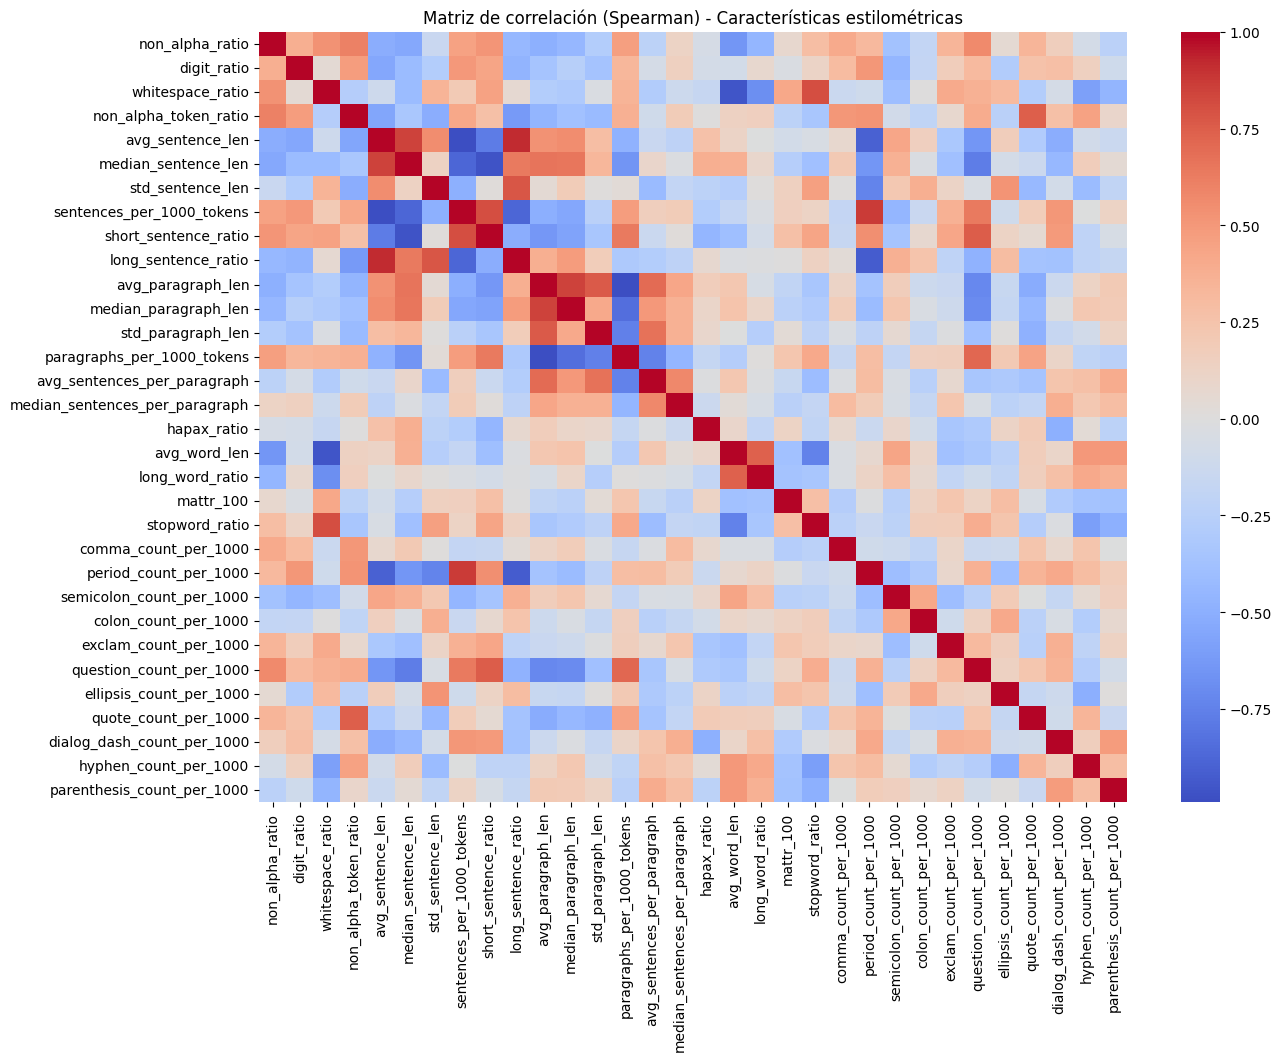

In [17]:
# Calculamos la matriz de correlación entre las características estilométricas
corr_base = X_base_train.corr(method="spearman")  # más robusto que Pearson para este caso

# Visualizamos la matriz de correlación
plt.figure(figsize=(14, 10))
sns.heatmap(corr_base, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación (Spearman) - Características estilométricas")
plt.show()

Ahora vamos a mostrar qué pares de características tienen una correlación mayor a nuestro umbral establecido (`CORRELATION_THRESHOLD`), para poder decidir cuáles de estas características vamos a eliminar del conjunto de datos de entrenamiento y test para el experimento.

In [18]:
# Pares muy correlacionados
corr_pairs = corr_base.where(np.triu(np.ones(corr_base.shape), k=1).astype(bool)).stack().reset_index()
corr_pairs.columns = ["feature_1", "feature_2", "corr"]

high_corr_pairs = corr_pairs.loc[corr_pairs["corr"].abs() >= CORRELATION_THRESHOLD].sort_values(
    "corr", key=np.abs, ascending=False
)

high_corr_pairs.head(20)

,feature_1,feature_2,corr
333,avg_paragraph_len,paragraphs_per_1000_tokens,-0.990618
135,avg_sentence_len,sentences_per_1000_tokens,-0.983019
168,median_sentence_len,short_sentence_ratio,-0.960991
81,whitespace_ratio,avg_word_len,-0.959511
310,long_sentence_ratio,period_count_per_1000,-0.922253
137,avg_sentence_len,long_sentence_ratio,0.914802
150,avg_sentence_len,period_count_per_1000,-0.903782
167,median_sentence_len,sentences_per_1000_tokens,-0.877288
233,sentences_per_1000_tokens,long_sentence_ratio,-0.875530
246,sentences_per_1000_tokens,period_count_per_1000,0.875026


A continuación, vamos a calcular cuántas características nos quedarían si eliminamos aquellas que estén altamente correlacionadas entre sí, y vamos a mostrar cuáles son estas características que se eliminarían.

In [19]:
base_features_corr_kept, base_features_corr_dropped, upper_corr = drop_highly_correlated_features(
    X_base_train, threshold=CORRELATION_THRESHOLD
)

print("Nº de características originales:", len(base_features))
print("Nº tras filtro de correlación:", len(base_features_corr_kept))
print("Características a eliminar:", base_features_corr_dropped)

Nº de características originales: 32
Nº tras filtro de correlación: 25
Características a eliminar: ['median_sentence_len', 'sentences_per_1000_tokens', 'short_sentence_ratio', 'long_sentence_ratio', 'paragraphs_per_1000_tokens', 'avg_word_len', 'period_count_per_1000']


Ahora, en base al parámetro de configuración `KEEP_CORRELATED_FEATURES`, vamos a decidir si nos quedamos solo con las características que no estén altamente correlacionadas entre sí, o bien vamos a quedarnos con todas las características sin eliminar ninguna.

In [20]:
if not KEEP_CORRELATED_FEATURES:
    base_features = base_features_corr_kept
    train_base = train_df[["file_name", "author_norm"] + base_features].copy()
    test_base = test_df[["file_name", "author_norm"] + base_features].copy()

print("Train base shape:", train_base.shape)
print("Test base shape:", test_base.shape)

Train base shape: (83, 27)
Test base shape: (12, 27)


In [21]:
print("Dataset base features:", train_base.columns)

Dataset base features: Index(['file_name', 'author_norm', 'non_alpha_ratio', 'digit_ratio',
       'whitespace_ratio', 'non_alpha_token_ratio', 'avg_sentence_len',
       'std_sentence_len', 'avg_paragraph_len', 'median_paragraph_len',
       'std_paragraph_len', 'avg_sentences_per_paragraph',
       'median_sentences_per_paragraph', 'hapax_ratio', 'long_word_ratio',
       'mattr_100', 'stopword_ratio', 'comma_count_per_1000',
       'semicolon_count_per_1000', 'colon_count_per_1000',
       'exclam_count_per_1000', 'question_count_per_1000',
       'ellipsis_count_per_1000', 'quote_count_per_1000',
       'dialog_dash_count_per_1000', 'hyphen_count_per_1000',
       'parenthesis_count_per_1000'],
      dtype='str')


### Dataset de palabras funcionales más frecuentes (MFW)

Este dataset lo vamos a utilizar para el experimento de solo las MFW y va a estar compuesto por las características correspondientes a las `TOP_N_MFW` palabras más frecuentes en nuestro corpus, calculadas a partir del conjunto de entrenamiento.

De nuevo, añadimos `file_name`como idntificador de cada texto, y `author_norm` como variable objetivo.

In [22]:
fw_cols = [c for c in train_mfw_df.columns if c.startswith("fw_")]

train_fw = train_df[["file_name", "author_norm"]].merge(
    train_mfw_df[["file_name"] + fw_cols], on="file_name", how="inner"
)

test_fw = test_df[["file_name", "author_norm"]].merge(test_mfw_df[["file_name"] + fw_cols], on="file_name", how="inner")

In [23]:
print("Train FW shape:", train_fw.shape)
print("Test FW shape:", test_fw.shape)

Train FW shape: (83, 52)
Test FW shape: (12, 52)


In [24]:
print("Dataset MFW features:", train_fw.columns)

Dataset MFW features: Index(['file_name', 'author_norm', 'fw_the', 'fw_and', 'fw_to', 'fw_of',
       'fw_i', 'fw_a', 'fw_in', 'fw_was', 'fw_he', 'fw_that', 'fw_it',
       'fw_you', 'fw_his', 'fw_had', 'fw_with', 'fw_her', 'fw_as', 'fw_my',
       'fw_for', 'fw_but', 'fw_at', 'fw_is', 'fw_she', 'fw_not', 'fw_have',
       'fw_on', 'fw_me', 'fw_this', 'fw_which', 'fw_be', 'fw_him', 'fw_from',
       'fw_by', 'fw_one', 'fw_if', 'fw_no', 'fw_all', 'fw_what', 'fw_so',
       'fw_there', 'fw_we', 'fw_an', 'fw_been', 'fw_when', 'fw_or', 'fw_were',
       'fw_would', 'fw_will', 'fw_out', 'fw_your'],
      dtype='str')


### Dataset combinado (base + MFW)

Este dataset lo vamos a utilizar para el experimento de las métricas de estilometría + las MFW, y va a estar compuesto por todas las características del dataset base (métricas de estilometría) y las características correspondientes a las `TOP_N_MFW` palabras más frecuentes en nuestro corpus.

In [25]:
train_combined = train_base.merge(train_mfw_df[["file_name"] + fw_cols], on="file_name", how="inner")

test_combined = test_base.merge(test_mfw_df[["file_name"] + fw_cols], on="file_name", how="inner")

In [26]:
print("Train combined shape:", train_combined.shape)
print("Test combined shape:", test_combined.shape)

Train combined shape: (83, 77)
Test combined shape: (12, 77)


In [27]:
print("Dataset combined features:", train_combined.columns)

Dataset combined features: Index(['file_name', 'author_norm', 'non_alpha_ratio', 'digit_ratio',
       'whitespace_ratio', 'non_alpha_token_ratio', 'avg_sentence_len',
       'std_sentence_len', 'avg_paragraph_len', 'median_paragraph_len',
       'std_paragraph_len', 'avg_sentences_per_paragraph',
       'median_sentences_per_paragraph', 'hapax_ratio', 'long_word_ratio',
       'mattr_100', 'stopword_ratio', 'comma_count_per_1000',
       'semicolon_count_per_1000', 'colon_count_per_1000',
       'exclam_count_per_1000', 'question_count_per_1000',
       'ellipsis_count_per_1000', 'quote_count_per_1000',
       'dialog_dash_count_per_1000', 'hyphen_count_per_1000',
       'parenthesis_count_per_1000', 'fw_the', 'fw_and', 'fw_to', 'fw_of',
       'fw_i', 'fw_a', 'fw_in', 'fw_was', 'fw_he', 'fw_that', 'fw_it',
       'fw_you', 'fw_his', 'fw_had', 'fw_with', 'fw_her', 'fw_as', 'fw_my',
       'fw_for', 'fw_but', 'fw_at', 'fw_is', 'fw_she', 'fw_not', 'fw_have',
       'fw_on', 'fw_me', 'fw

## Definición de los modelos de *machine learning*

Vamos a utilizar los siguientes modelos de *machine learning* para nuestros experimentos:

* **Regresión logística.** Es un modelo de clasificación lineal que estima la probabilidad de que una muestra pertenezca a una clase. Es simple, interpretable y suele funcionar bien como línea base en problemas de clasificación.
* **Linear SVC.** Es una máquina de soporte vectorial con frontera de decisión lineal, diseñada para separar clases maximizando el margen entre ellas. Suele ser eficaz en datos de alta dimensión, como texto o variables muy numerosas.
* **SVC con kernel RBF.** Es una versión no lineal de las máquinas de soporte vectorial que utiliza un kernel gaussiano para capturar relaciones complejas entre variables. Es útil cuando las clases no pueden separarse con una frontera lineal.
* **Random Forest.** Es un conjunto de árboles de decisión entrenados sobre distintas muestras y subconjuntos de variables, cuyas predicciones se combinan. Suele ofrecer buen rendimiento, manejar relaciones no lineales y ser robusto frente al sobreajuste.
* **KNN.** Es un método basado en proximidad que clasifica una muestra según las clases de sus vecinos más cercanos. Es fácil de entender, aunque su rendimiento depende bastante de la escala de los datos y de la elección de *k*.
* **Naive Bayes.** Es un clasificador probabilístico basado en el teorema de Bayes que asume independencia entre variables predictoras. A pesar de esa suposición simplificadora, suele ser rápido y competitivo en tareas como clasificación de texto.

Esta selección de modelos es adecuada porque combina enfoques lineales, no lineales, probabilísticos y basados en vecindad, lo que permite evaluar distintos tipos de patrones presentes en variables estilométricas y frecuencias de palabras funcionales. Además, al tratarse de rasgos cuantitativos que pueden incluir tanto relaciones simples como interacciones más complejas entre características, comparar estos modelos ofrece una base sólida para identificar cuál captura mejor la señal de autoría.

Además, esta combinación permite comparar modelos más interpretables, como la regresión logística o Naive Bayes, con otros más complejos, lo que facilita analizar no solo qué sistema clasifica mejor, sino también hasta qué punto los resultados pueden explicarse.

In [28]:
models = {
    "logreg": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED),
    "linear_svc": LinearSVC(class_weight="balanced", random_state=SEED, max_iter=10000),
    "svc_rbf": SVC(kernel="rbf", class_weight="balanced", random_state=SEED),
    "random_forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED),
    "knn": KNeighborsClassifier(n_neighbors=3),
    "gaussian_nb": GaussianNB(),
}

## Ejecución de los experimentos

En esta sección vamos a ejecutar los experimentos con cada uno de los conjuntos de características que hemos preparado (base, MFW y combinado) y con cada uno de los modelos que hemos seleccionado. Para ello, vamos a utilizar la función `run_experiment` que hemos definido previamente, y vamos a guardar los resultados de cada experimento en un DataFrame para poder compararlos posteriormente.

La función `run_experiment` compara varios modelos de clasificación mediante validación cruzada sobre el conjunto de entrenamiento, aplicando en todos ellos un preprocesamiento común con imputación de valores ausentes y un escalado robusto. Después, selecciona el modelo con mejor rendimiento medio, lo ajusta con todos los datos de entrenamiento y evalúa su desempeño final en el conjunto de prueba.

### Solo features estilométricas

In [29]:
base_result = run_experiment(
    train_data=train_base,
    test_data=test_base,
    feature_cols=base_features,
    author_col="author_norm",
    models=models,
    seed=SEED,
)

### Solo palabras funcionales más frecuentes (MFW)

In [30]:
fw_features = fw_cols

fw_result = run_experiment(
    train_data=train_fw, test_data=test_fw, feature_cols=fw_features, author_col="author_norm", models=models, seed=SEED
)

### Features combinados (base + MFW)

In [31]:
combined_features = base_features + fw_cols

combined_result = run_experiment(
    train_data=train_combined,
    test_data=test_combined,
    feature_cols=combined_features,
    author_col="author_norm",
    models=models,
    seed=SEED,
)

## Obtención de resultados y análisis de los experimentos

Una vez que hemos ejecutado los experimentos, vamos a analizar los resultados obtenidos para cada uno de ellos, comparando el rendimiento de los distintos modelos y conjuntos de características. Para ello, vamos a utilizar las métricas de precisión, recall, F1-score y accuracy, así como la matriz de confusión, y vamos a mostrar estos resultados en forma de tablas y gráficos para interpretarlos.

Se ha obtado por F1-macro como métrica principal para evaluar el rendimiento de los modelos ya que es una buena métrica en clasificación multiclase porque calcula la F1 de cada clase por separado y luego les da el mismo peso al promediarlas, evitando que las clases más frecuentes dominen la evaluación. Por eso resulta especialmente útil cuando existe desbalance entre clases, como es nuestro caso, y se quiere medir de forma más justa la capacidad del modelo para reconocer bien todas las categorías.

In [32]:
# Creamos un DataFrame resumen con los resultados de los experimentos
summary_df = pd.DataFrame(
    [
        {
            "experiment": "base_features",
            "best_model": base_result["best_model_name"],
            "cv_best_mean": base_result["cv_results"].iloc[0]["cv_mean"],
            "test_f1_macro": base_result["test_f1_macro"],
            "n_features": len(base_features),
        },
        {
            "experiment": "function_words",
            "best_model": fw_result["best_model_name"],
            "cv_best_mean": fw_result["cv_results"].iloc[0]["cv_mean"],
            "test_f1_macro": fw_result["test_f1_macro"],
            "n_features": len(fw_features),
        },
        {
            "experiment": "combined",
            "best_model": combined_result["best_model_name"],
            "cv_best_mean": combined_result["cv_results"].iloc[0]["cv_mean"],
            "test_f1_macro": combined_result["test_f1_macro"],
            "n_features": len(combined_features),
        },
    ]
).sort_values("test_f1_macro", ascending=False)

summary_df

,experiment,best_model,cv_best_mean,test_f1_macro,n_features
1,function_words,linear_svc,1.000000,1.000000,50
2,combined,linear_svc,1.000000,1.000000,75
0,base_features,logreg,0.942734,0.911111,25


Los resultados indican que los conjuntos de datos que incluyen **palabras funcionales**, ya sea por sí solas (*function_words*) o combinadas con las variables estilométricas (*combined*), ofrecen el mejor rendimiento, alcanzando en esta ejecución (`SEED = 42`, `TOP_N_MFW = 50` y `KEEP_CORRELATED_FEATURES = False`) un F1-macro de 1.000 tanto en validación cruzada como en test. En ambos casos, el mejor modelo es **Linear SVC**, lo que sugiere que este tipo de variables proporciona una señal muy discriminativa para la tarea de atribución de autoría.

Por el contrario, el conjunto basado únicamente en **características estilométricas** (*base_features*) obtiene un rendimiento algo inferior, con un F1-macro de 0.943 en validación cruzada y 0.911 en test, siendo en este caso la **regresión logística** el mejor modelo. Esto sugiere que, aunque las métricas estilométricas capturan parte del estilo de los autores, por sí solas no parecen contener tanta capacidad discriminativa como las palabras funcionales.

Además, al repetir los experimentos con distintas semillas y parámetros, los resultados suelen ser bastante estables, alternándose de forma consistente **Linear SVC** y **regresión logística** como mejores modelos. En particular, los mejores resultados se observan siempre en los conjuntos que incluyen **palabras funcionales**, ya sea solas o combinadas con las características estilométricas, mientras que el conjunto formado únicamente por rasgos estilométricos no parece alcanzar nunca el 100 % en las diferentes ejecuciones.

Vamos ahora a analizar con más detalle los resultados obtenidos en cada uno de los experimentos, comparando las métricas de precisión, recall, F1-score y accuracy para cada clase, así como la matriz de confusión, para entender mejor cómo se están clasificando los textos de cada autor y qué errores se están cometiendo.

### Métricas de evaluación con base features

In [33]:
bs_model_name = base_result["best_model_name"].upper()
print(
    f"Mejor modelo para características estilométricas: {bs_model_name} con F1-macro en test de {base_result['test_f1_macro']:.4f}."
)

Mejor modelo para características estilométricas: LOGREG con F1-macro en test de 0.9111.


In [34]:
print(f"\n=== INFORME DE CLASIFICACIÓN EN TEST DE {bs_model_name} CON BASE FEATURES ===")
print(base_result["classification_report"])


=== INFORME DE CLASIFICACIÓN EN TEST DE LOGREG CON BASE FEATURES ===
                          precision    recall  f1-score   support

    anna_katharine_green       0.67      1.00      0.80         2
      arthur_conan_doyle       1.00      1.00      1.00         2
         arthur_morrison       1.00      1.00      1.00         2
gilbert_keith_chesterton       1.00      1.00      1.00         2
  richard_austin_freeman       1.00      0.50      0.67         2
          wilkie_collins       1.00      1.00      1.00         2

                accuracy                           0.92        12
               macro avg       0.94      0.92      0.91        12
            weighted avg       0.94      0.92      0.91        12



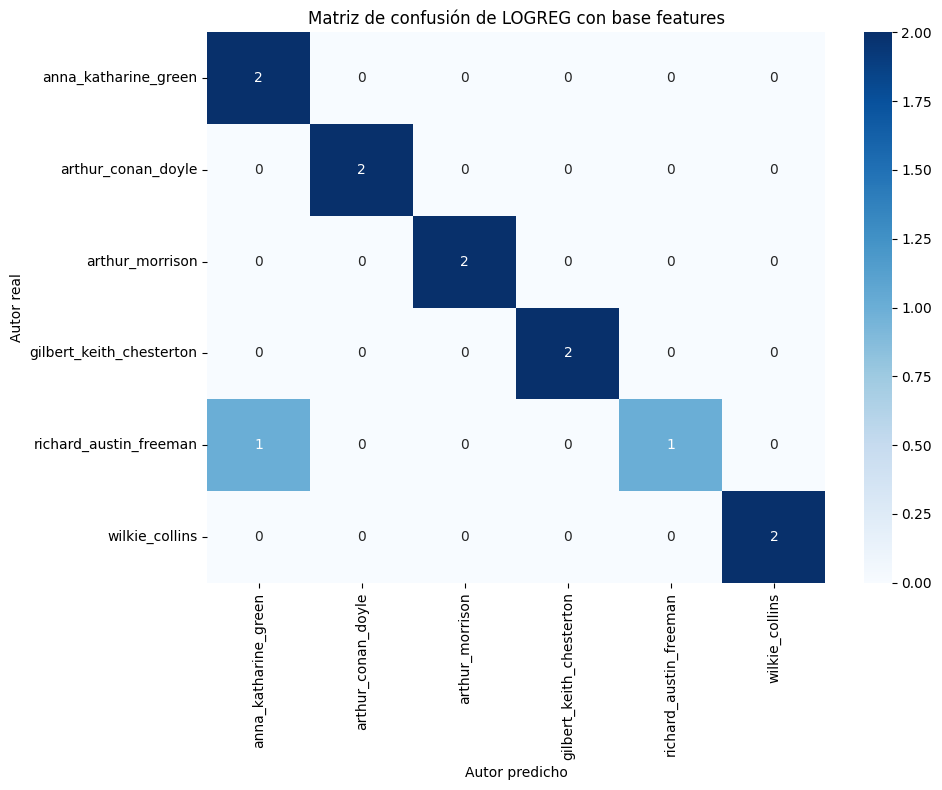

In [35]:
plot_confussion_matrix(
    cm=base_result["confusion_matrix"], labels=base_result["labels"], model_name=bs_model_name, features="base features"
)

In [36]:
print(f"\n=== PREDICCIONES EN TEST DE {bs_model_name} CON BASE FEATURES ===")
pred_df = test_df[["file_name", "title", "genre", "author_norm"]].copy()
pred_df = pred_df.merge(
    base_result["pred_df"][["file_name", "pred_author", "correct"]],
    left_on="file_name",
    right_on="file_name",
    how="inner",
)
pred_df.sort_values(["author_norm", "genre", "title"])


=== PREDICCIONES EN TEST DE LOGREG CON BASE FEATURES ===


,file_name,title,genre,author_norm,pred_author,correct
1,akg-to_the_minute,To the Minute,fiction,anna_katharine_green,anna_katharine_green,True
0,akg-three_thousand_dollars,Three Thousand Dollars,mystery,anna_katharine_green,anna_katharine_green,True
2,acd-the_adventures_of_sherlock_holmes,The Adventures of Sherlock Holmes,mystery,arthur_conan_doyle,arthur_conan_doyle,True
3,acd-the_lost_world,The Lost World,scifi,arthur_conan_doyle,arthur_conan_doyle,True
5,am-the_hole_in_the_wall,The Hole in the Wall,fiction,arthur_morrison,arthur_morrison,True
4,am-chronicles_of_martin_hewitt,Chronicles of Martin Hewitt,mystery,arthur_morrison,arthur_morrison,True
7,gkc-the_return_of_don_quixote,The Return of Don Quixote,fiction,gilbert_keith_chesterton,gilbert_keith_chesterton,True
6,gkc-four_faultless_felons,Four Faultless Felons,mystery,gilbert_keith_chesterton,gilbert_keith_chesterton,True
9,raf-the_golden_pool,The golden pool,fiction,richard_austin_freeman,anna_katharine_green,False
8,raf-the_shadow_of_the_wolf,The shadow of the Wolf,mystery,richard_austin_freeman,richard_austin_freeman,True


El único error del modelo basado exclusivamente en características estilométricas corresponde a The Golden Pool, de Richard Austin Freeman, clasificado como Anna Katharine Green. Este resultado sugiere que, aunque los rasgos estilométricos capturan en gran medida la señal de autoría, en casos concretos pueden resultar insuficientes para distinguir textos con perfiles cuantitativos similares, especialmente cuando existen variaciones internas en la obra o por efectos del género y/o el registro.

### Métricas de evaluación con palabras funcionales más frecuentes (MFW)

In [37]:
fw_model_name = fw_result["best_model_name"].upper()
print(f"Mejor modelo para MFW: {fw_model_name} con F1-macro en test de {fw_result['test_f1_macro']:.4f}.")

Mejor modelo para MFW: LINEAR_SVC con F1-macro en test de 1.0000.


In [38]:
print(f"\n=== INFORME DE CLASIFICACIÓN EN TEST DE {fw_model_name} CON MFW ===")
print(fw_result["classification_report"])


=== INFORME DE CLASIFICACIÓN EN TEST DE LINEAR_SVC CON MFW ===
                          precision    recall  f1-score   support

    anna_katharine_green       1.00      1.00      1.00         2
      arthur_conan_doyle       1.00      1.00      1.00         2
         arthur_morrison       1.00      1.00      1.00         2
gilbert_keith_chesterton       1.00      1.00      1.00         2
  richard_austin_freeman       1.00      1.00      1.00         2
          wilkie_collins       1.00      1.00      1.00         2

                accuracy                           1.00        12
               macro avg       1.00      1.00      1.00        12
            weighted avg       1.00      1.00      1.00        12



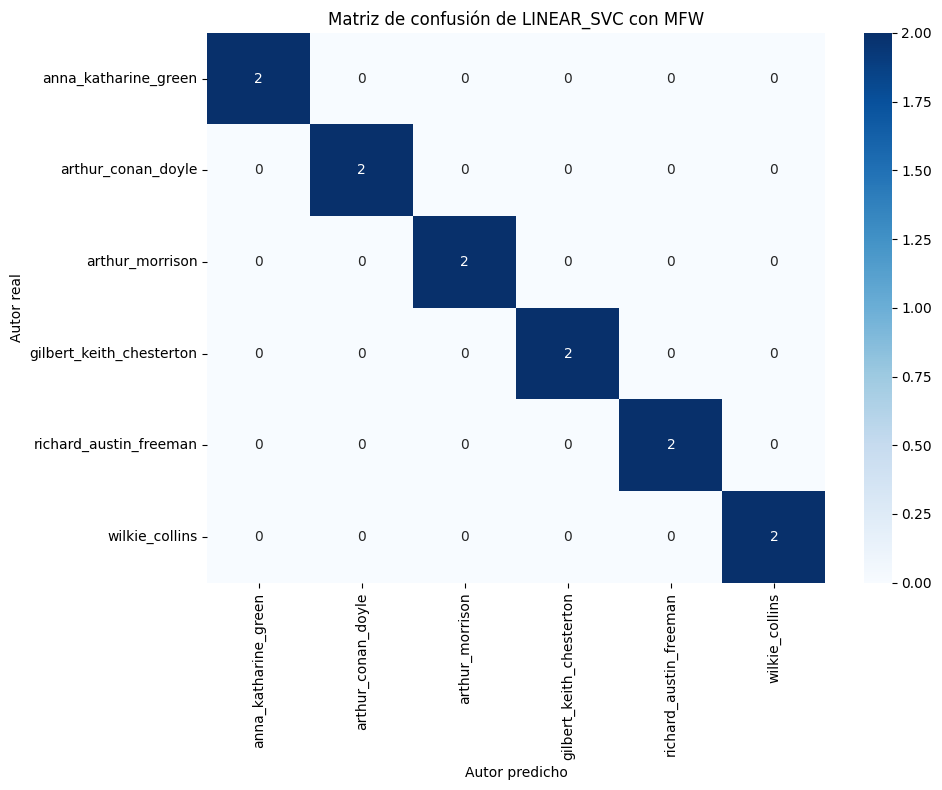

In [39]:
plot_confussion_matrix(
    cm=fw_result["confusion_matrix"], labels=fw_result["labels"], model_name=fw_model_name, features="MFW"
)

In [40]:
print(f"\n=== PREDICCIONES EN TEST DE {fw_model_name} CON MFW ===")
pred_df = test_df[["file_name", "title", "genre", "author_norm"]].copy()
pred_df = pred_df.merge(
    fw_result["pred_df"][["file_name", "pred_author", "correct"]],
    left_on="file_name",
    right_on="file_name",
    how="inner",
)
pred_df.sort_values(["author_norm", "genre", "title"])


=== PREDICCIONES EN TEST DE LINEAR_SVC CON MFW ===


,file_name,title,genre,author_norm,pred_author,correct
1,akg-to_the_minute,To the Minute,fiction,anna_katharine_green,anna_katharine_green,True
0,akg-three_thousand_dollars,Three Thousand Dollars,mystery,anna_katharine_green,anna_katharine_green,True
2,acd-the_adventures_of_sherlock_holmes,The Adventures of Sherlock Holmes,mystery,arthur_conan_doyle,arthur_conan_doyle,True
3,acd-the_lost_world,The Lost World,scifi,arthur_conan_doyle,arthur_conan_doyle,True
5,am-the_hole_in_the_wall,The Hole in the Wall,fiction,arthur_morrison,arthur_morrison,True
4,am-chronicles_of_martin_hewitt,Chronicles of Martin Hewitt,mystery,arthur_morrison,arthur_morrison,True
7,gkc-the_return_of_don_quixote,The Return of Don Quixote,fiction,gilbert_keith_chesterton,gilbert_keith_chesterton,True
6,gkc-four_faultless_felons,Four Faultless Felons,mystery,gilbert_keith_chesterton,gilbert_keith_chesterton,True
9,raf-the_golden_pool,The golden pool,fiction,richard_austin_freeman,richard_austin_freeman,True
8,raf-the_shadow_of_the_wolf,The shadow of the Wolf,mystery,richard_austin_freeman,richard_austin_freeman,True


Observamos que el modelo basado en palabras funcionales más frecuentes (MFW) clasifica correctamente todos los textos de test, alcanzando un F1-macro de 1.000. Esto indica que las frecuencias de estas palabras funcionales son altamente discriminativas para distinguir entre los autores presentes en nuestro corpus, lo que refuerza la idea de que estas características capturan aspectos fundamentales del estilo de autoría.

### Métricas de evaluación con features combinados (base + MFW)

In [41]:
combined_model_name = combined_result["best_model_name"].upper()
print(
    f"Mejor modelo para características combinadas: {combined_model_name} con F1-macro en test de {combined_result['test_f1_macro']:.4f}."
)

Mejor modelo para características combinadas: LINEAR_SVC con F1-macro en test de 1.0000.


In [42]:
print(f"\n=== INFORME DE CLASIFICACIÓN EN TEST DE {combined_model_name} CON COMBINED FEATURES ===")
print(combined_result["classification_report"])


=== INFORME DE CLASIFICACIÓN EN TEST DE LINEAR_SVC CON COMBINED FEATURES ===
                          precision    recall  f1-score   support

    anna_katharine_green       1.00      1.00      1.00         2
      arthur_conan_doyle       1.00      1.00      1.00         2
         arthur_morrison       1.00      1.00      1.00         2
gilbert_keith_chesterton       1.00      1.00      1.00         2
  richard_austin_freeman       1.00      1.00      1.00         2
          wilkie_collins       1.00      1.00      1.00         2

                accuracy                           1.00        12
               macro avg       1.00      1.00      1.00        12
            weighted avg       1.00      1.00      1.00        12



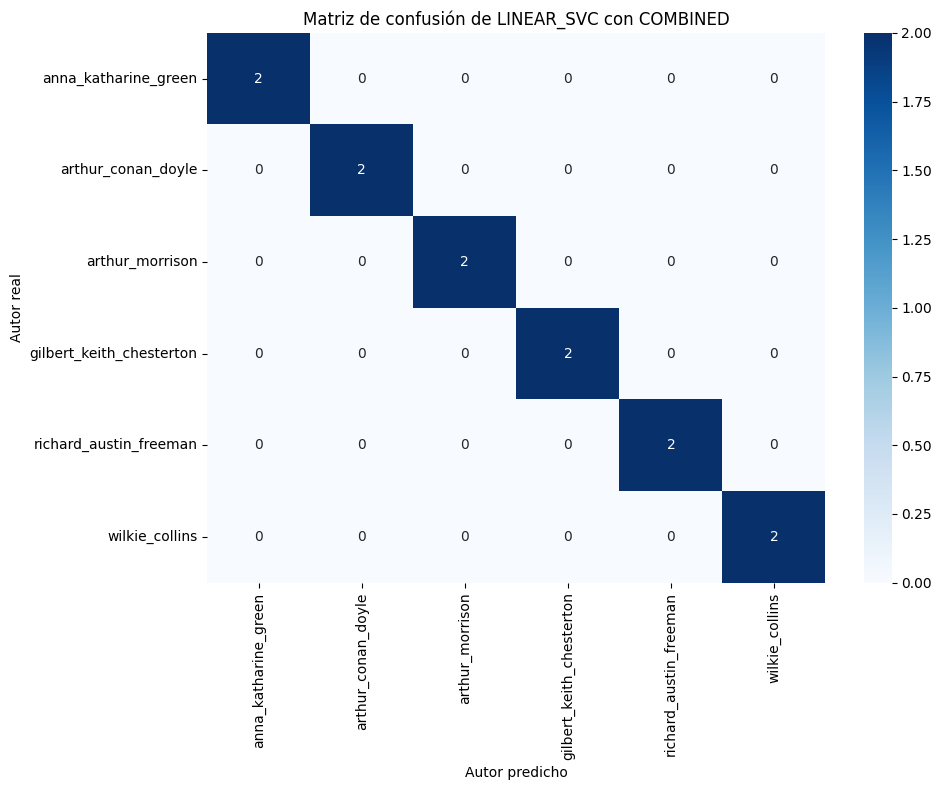

In [43]:
plot_confussion_matrix(
    cm=combined_result["confusion_matrix"],
    labels=combined_result["labels"],
    model_name=combined_model_name,
    features="COMBINED",
)

In [44]:
print(f"\n=== PREDICCIONES EN TEST DE {combined_model_name} CON COMBINED FEATURES ===")
pred_df = test_df[["file_name", "title", "genre", "author_norm"]].copy()
pred_df = pred_df.merge(
    combined_result["pred_df"][["file_name", "pred_author", "correct"]],
    left_on="file_name",
    right_on="file_name",
    how="inner",
)
pred_df.sort_values(["author_norm", "genre", "title"])


=== PREDICCIONES EN TEST DE LINEAR_SVC CON COMBINED FEATURES ===


,file_name,title,genre,author_norm,pred_author,correct
1,akg-to_the_minute,To the Minute,fiction,anna_katharine_green,anna_katharine_green,True
0,akg-three_thousand_dollars,Three Thousand Dollars,mystery,anna_katharine_green,anna_katharine_green,True
2,acd-the_adventures_of_sherlock_holmes,The Adventures of Sherlock Holmes,mystery,arthur_conan_doyle,arthur_conan_doyle,True
3,acd-the_lost_world,The Lost World,scifi,arthur_conan_doyle,arthur_conan_doyle,True
5,am-the_hole_in_the_wall,The Hole in the Wall,fiction,arthur_morrison,arthur_morrison,True
4,am-chronicles_of_martin_hewitt,Chronicles of Martin Hewitt,mystery,arthur_morrison,arthur_morrison,True
7,gkc-the_return_of_don_quixote,The Return of Don Quixote,fiction,gilbert_keith_chesterton,gilbert_keith_chesterton,True
6,gkc-four_faultless_felons,Four Faultless Felons,mystery,gilbert_keith_chesterton,gilbert_keith_chesterton,True
9,raf-the_golden_pool,The golden pool,fiction,richard_austin_freeman,richard_austin_freeman,True
8,raf-the_shadow_of_the_wolf,The shadow of the Wolf,mystery,richard_austin_freeman,richard_austin_freeman,True


De nuevo, el modelo basado en características combinadas (base + MFW) clasifica correctamente todos los textos de test, alcanzando un F1-macro de 1.000. Esto sugiere que la combinación de métricas estilométricas con las frecuencias de palabras funcionales mantiene la capacidad discriminativa de estas últimas, y que estas no parecen meter ruido que pueda afectar negativamente al rendimiento del modelo.

## Exportar el mejor modelo

A continuación, mostramos como exportar el mejor modelo obtenido en un experimento para poder utilizarlo posteriormente en nuevas predicciones o análisis.

Junto con el *pipeline* del modelo, también se exportan los conjuntos de entrenamiento y test utilizados en el experimento, así como la lista de características utilizadas para entrenar el modelo y los metadatos del experimento.

En este caso, vamos a exportar el mejor modelo obtenido en el experimento con características MFW, ya que parece que ha obtenido un rendimiento equiparable al combinado con menos características, lo que podría facilitar su interpretación.

In [45]:
# Exportamos el pipeline (preprocesado + modelo final)
dump(fw_result["best_pipeline"], ML_ARTIFACTS_PATH / "fw_model.joblib")

# Exportamos los conjuntos de entrenamiento y test
# utilizados en el experimento
train_fw.to_parquet(ML_ARTIFACTS_PATH / "train_fw.parquet", index=False)
test_fw.to_parquet(ML_ARTIFACTS_PATH / "test_fw.parquet", index=False)

# Generamos un diccionario con los metadatos del
# experimento para documentar el modelo exportado
metadata = {
    "model_name": "best_fw_pipeline",
    "selected_model": fw_result["best_model_name"],
    "target": "author_norm",
    "feature_columns": fw_cols,
    "n_features": len(train_fw.columns),
    "n_train_samples": len(train_fw),
    "n_test_samples": len(test_fw),
    "metrics": {
        "test_f1_macro": fw_result["test_f1_macro"],
    },
    "train_notebook": "03_supervised_ml_methods.ipynb",
    "split_seed": SEED,
}

with open(ML_ARTIFACTS_PATH / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)